In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/dataset_final.zip" -d "/content/dataset"

In [ ]:
!pip install torch torchvision timm scikit-learn tensorboard tqdm

In [ ]:

import os, json, math, logging, argparse
import numpy as np
from pathlib import Path
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.tensorboard import SummaryWriter
import timm
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score
from tqdm import tqdm

os.environ.setdefault("PYTORCH_ALLOC_CONF", "expandable_segments:True")
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)


# Config

class TrainConfig:
    data_root:    str  = "/content/dataset/dataset_final"
    dataset_tag:  str  = "proprietary"
    num_classes:  int  = 55
    max_frames:   int  = 90
    roi_size:     int  = 224
    dinov2_model: str  = "vit_small_patch14_dinov2"
    embed_dim:    int  = 384

    d_model:         int   = 384
    nhead:           int   = 4
    num_tf_layers:   int   = 4
    dim_feedforward: int   = 1024
    dropout:         float = 0.3

    batch_size:      int   = 64
    lr:              float = 3e-5
    weight_decay:    float = 1e-4
    lr_patience:     int   = 5
    lr_factor:       float = 0.5
    early_stop_patience: int = 10
    epochs:          int   = 50

    extract_chunk:   int   = 8

    checkpoint_dir: str  = "checkpoints"
    log_dir:        str  = "runs"
    seed:           int  = 42
    num_workers:    int  = 0
    pin_memory:     bool = True
    freeze_backbone: bool  = False


# Label map

def load_label_map(data_root: str, dataset_tag: str) -> dict:
    p = Path(data_root) / dataset_tag / "label_map.json"
    if p.exists():
        return json.loads(p.read_text(encoding="utf-8"))
    logger.warning("Building label map from train split.")
    train_path = Path(data_root) / dataset_tag / "train"
    classes    = sorted(d.name for d in train_path.iterdir() if d.is_dir())
    lm         = {c: i for i, c in enumerate(classes)}
    p.write_text(json.dumps(lm, ensure_ascii=False, indent=2), encoding="utf-8")
    return lm


# Feature Extraction

def extract_features(cfg: TrainConfig):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    logger.info("Extracting on: %s", device)

    backbone = timm.create_model(
        cfg.dinov2_model, pretrained=True, num_classes=0,
        img_size=cfg.roi_size, dynamic_img_size=True,
    ).to(device).eval()
    for p in backbone.parameters():
        p.requires_grad_(False)

    _MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
    _STD  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)
    label_to_id = load_label_map(cfg.data_root, cfg.dataset_tag)
    saved = skipped = 0

    for split in ("train", "val", "test"):
        split_path = Path(cfg.data_root) / cfg.dataset_tag / split
        if not split_path.exists():
            continue
        npz_files = sorted(split_path.rglob("*.npz"))
        logger.info("[%s] %d files.", split, len(npz_files))

        for npz_path in tqdm(npz_files, desc=f"Extract {split}"):
            feat_path = npz_path.with_suffix(".pt")
            if feat_path.exists():
                skipped += 1
                continue

            data   = np.load(npz_path)
            key    = "frames" if "frames" in data.files else data.files[0]
            frames = data[key]
            seq    = torch.from_numpy(frames).float()

            if seq.max() > 2.5:
                seq = seq / 255.0
                seq = seq.permute(0, 3, 1, 2)
                seq = (seq - _MEAN.cpu()) / _STD.cpu()
            else:
                seq = seq.permute(0, 3, 1, 2)

            T = seq.size(0)
            if T >= cfg.max_frames:
                start = (T - cfg.max_frames) // 2
                seq   = seq[start: start + cfg.max_frames]
                mask  = torch.ones(cfg.max_frames, dtype=torch.bool)
            else:
                n_pad = cfg.max_frames - T
                seq   = torch.cat([seq, torch.zeros(n_pad, *seq.shape[1:])])
                mask  = torch.cat([torch.ones(T, dtype=torch.bool),
                                   torch.zeros(n_pad, dtype=torch.bool)])

            _, C, H, W = seq.shape
            if H != cfg.roi_size or W != cfg.roi_size:
                seq = F.interpolate(seq, size=(cfg.roi_size, cfg.roi_size),
                                    mode="bilinear", align_corners=False)

            seq = seq.to(device)
            chunks = []
            with torch.no_grad():
                for chunk in seq.split(cfg.extract_chunk, dim=0):
                    f = backbone.forward_features(chunk)
                    if isinstance(f, dict):
                        if "x_norm_clstoken" in f:
                            f = f["x_norm_clstoken"]
                        elif "x_norm_patchtokens" in f:
                            f = f["x_norm_patchtokens"].mean(dim=1)
                        else:
                            f = list(f.values())[0]
                            if f.dim() == 3:
                                f = f.mean(dim=1)
                    elif f.dim() == 3:
                        f = f[:, 0]
                    chunks.append(f.cpu())

            feats = torch.cat(chunks, dim=0)
            torch.save({"feats": feats, "mask": mask,
                        "label": torch.tensor(label_to_id[npz_path.parent.name],
                                              dtype=torch.long)},
                       feat_path)
            saved += 1

    logger.info("Done. Saved: %d | Skipped: %d", saved, skipped)


# Dataset

class FeatureDataset(Dataset):
    def __init__(self, root: str, split: str, dataset_tag: str):
        split_path = Path(root) / dataset_tag / split
        if not split_path.exists():
            raise FileNotFoundError(f"Not found: {split_path}")
        self.samples = sorted(split_path.rglob("*.pt"))
        if not self.samples:
            raise RuntimeError(f"No .pt files in {split_path}. Run --mode extract first.")
        logger.info("[%s/%s] %d samples.", dataset_tag, split, len(self.samples))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        d = torch.load(self.samples[idx], weights_only=True)
        return d["feats"], d["mask"], d["label"]


def collate_fn(batch):
    f, m, l = zip(*batch)
    return torch.stack(f), torch.stack(m), torch.stack(l)


# Model

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int, dropout: float = 0.1):

        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


class TemporalHead(nn.Module):
    def __init__(self, cfg: TrainConfig):
        super().__init__()
        self.input_norm = nn.LayerNorm(cfg.embed_dim)

        self.proj = nn.Linear(cfg.embed_dim, cfg.d_model) \
                    if cfg.embed_dim != cfg.d_model else nn.Identity()


        self.pos_enc = PositionalEncoding(cfg.d_model, cfg.max_frames, cfg.dropout)

        enc = nn.TransformerEncoderLayer(
            d_model=cfg.d_model, nhead=cfg.nhead,
            dim_feedforward=cfg.dim_feedforward,
            dropout=cfg.dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc, cfg.num_tf_layers,
                                                  enable_nested_tensor=False)

        # Attention pooling
        self.attn_pool = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_model),
            nn.Tanh(),
            nn.Linear(cfg.d_model, 1),
        )


        self.norm = nn.LayerNorm(cfg.d_model)
        self.classifier = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_model),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(cfg.d_model, cfg.num_classes),
        )

    def forward(self, feats: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        x = self.input_norm(feats)
        x = self.proj(x)
        x = self.pos_enc(x)
        x = self.transformer(x, src_key_padding_mask=~mask)

        weights = self.attn_pool(x)                      # (B, T, 1)
        weights = weights.masked_fill(~mask.unsqueeze(-1), -1e9)
        weights = torch.softmax(weights, dim=1)
        pooled  = (x * weights).sum(dim=1)               # (B, d_model)

        return self.classifier(self.norm(pooled))


# Metrics

def compute_metrics(labels, preds, num_classes):
    acc = accuracy_score(labels, preds)
    return {
        "accuracy":         acc,
        "wer":              1 - acc,
        "f1_macro":         f1_score(labels, preds, average="macro",    zero_division=0),
        "f1_weighted":      f1_score(labels, preds, average="weighted", zero_division=0),
        "confusion_matrix": confusion_matrix(labels, preds,
                                             labels=list(range(num_classes))),
    }


def main(cfg: TrainConfig, mode: str):
    if mode == "extract":
        extract_features(cfg)
    elif mode == "train":
        train(cfg)
    else:
        extract_features(cfg)
        train(cfg)


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--mode", default="both",
                    choices=["extract", "train", "both"])
    ap.add_argument("--data_root",       default="/content/dataset/dataset_final")
    ap.add_argument("--dataset_tag",     default="proprietary")
    ap.add_argument("--num_classes",     type=int,   default=55)
    ap.add_argument("--max_frames",      type=int,   default=90)
    ap.add_argument("--roi_size",        type=int,   default=224)
    ap.add_argument("--dinov2_model",    default="vit_small_patch14_dinov2")
    ap.add_argument("--embed_dim",       type=int,   default=384)
    ap.add_argument("--d_model",         type=int,   default=384)
    ap.add_argument("--nhead",           type=int,   default=4)
    ap.add_argument("--num_tf_layers",   type=int,   default=4)
    ap.add_argument("--dim_feedforward", type=int,   default=1024)
    ap.add_argument("--batch_size",      type=int,   default=64)
    ap.add_argument("--epochs",          type=int,   default=50)
    ap.add_argument("--lr",              type=float, default=3e-5)
    ap.add_argument("--early_stop_patience", type=int, default=10)
    ap.add_argument("--checkpoint_dir",  default="checkpoints")
    ap.add_argument("--log_dir",         default="runs")
    ap.add_argument("--num_workers",     type=int,   default=0)
    args, _ = ap.parse_known_args()
    cfg = TrainConfig()
    for k, v in vars(args).items():
        if k != "mode":
            setattr(cfg, k, v)
    main(cfg, args.mode)

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Extract test: 100%|██████████| 703/703 [06:13<00:00,  1.88it/s]


NameError: name 'train' is not defined

In [ ]:
!python train_dinov2_v14.py --mode phase2 \
    --data_root /content/dataset/dataset_final \
    --dataset_tag proprietary

2026-04-24 05:56:49.041879: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777010209.082278   31049 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777010209.100828   31049 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777010209.141335   31049 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777010209.141369   31049 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777010209.141376   31049 computation_placer.cc:177] computation placer alr

In [ ]:
!python train_dinov2_v14.py --mode phase2 \
    --head_ckpt /content/best_model.pt \
    --data_root /content/dataset/dataset_final \
    --dataset_tag proprietary

2026-04-24 05:58:31.855564: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777010311.889993   31519 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777010311.901278   31519 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777010311.928323   31519 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777010311.928361   31519 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777010311.928369   31519 computation_placer.cc:177] computation placer alr

In [ ]:
!python train_dinov2_v13.py --mode train \
    --data_root /content/dataset/dataset_final \
    --dataset_tag proprietary \
    --batch_size 64 \
    --num_tf_layers 4 \
    --dim_feedforward 1024 \
    --dropout 0.5 \
    --lr 1e-4 \
    --weight_decay 5e-3 \
    --epochs 50 \
    --freeze_backbone = False

2026-04-19 17:52:38.721986: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776621158.761542   38722 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776621158.772965   38722 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776621158.800010   38722 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776621158.800047   38722 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776621158.800055   38722 computation_placer.cc:177] computation placer alr

In [ ]:
import os, json, math, logging, argparse
import numpy as np
from pathlib import Path
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.tensorboard import SummaryWriter
import timm
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score
from tqdm import tqdm

os.environ.setdefault("PYTORCH_ALLOC_CONF", "expandable_segments:True")
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)


# Config

class TrainConfig:
    data_root:    str  = "/content/dataset/dataset_final"
    dataset_tag:  str  = "proprietary"
    num_classes:  int  = 55
    max_frames:   int  = 90
    roi_size:     int  = 224          # 8×8 = 64 patches for ViT-S/14

    dinov2_model: str  = "vit_small_patch14_dinov2"
    embed_dim:    int  = 384          # ViT-S output dim
    freeze_backbone: bool  = True

    # Temporal Transformer (small, no backbone in loop)
    d_model:         int   = 384
    nhead:           int   = 4
    num_tf_layers:   int   = 4
    dim_feedforward: int   = 1024
    dropout:         float = 0.3

    # Training
    batch_size:         int   = 64
    accumulation_steps: int   = 2
    lr:                 float = 3e-5
    weight_decay:       float = 1e-4
    lr_patience:        int   = 5
    lr_factor:          float = 0.5
    epochs:             int   = 50

    # Extraction
    extract_batch_size: int   = 32    # images per batch during extraction
    extract_chunk:      int   = 8     # frames per DINOv2 chunk

    checkpoint_dir: str  = "checkpoints"
    log_dir:        str  = "runs"
    seed:           int  = 42
    num_workers:    int  = 0
    pin_memory:     bool = True


# Label map

def load_label_map(data_root: str, dataset_tag: str) -> dict:
    p = Path(data_root) / dataset_tag / "label_map.json"
    if p.exists():
        return json.loads(p.read_text(encoding="utf-8"))
    logger.warning("Building label map from train split.")
    train_path = Path(data_root) / dataset_tag / "train"
    classes    = sorted(d.name for d in train_path.iterdir() if d.is_dir())
    lm         = {c: i for i, c in enumerate(classes)}
    p.write_text(json.dumps(lm, ensure_ascii=False, indent=2), encoding="utf-8")
    return lm


# Feature Extraction

def extract_features(cfg: TrainConfig):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    logger.info("Extracting features on: %s", device)

    backbone = timm.create_model(
        cfg.dinov2_model, pretrained=True, num_classes=0,
        img_size=cfg.roi_size, dynamic_img_size=True,
    ).to(device).eval()
    for p in backbone.parameters():
        p.requires_grad_(False)

    _MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
    _STD  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

    label_to_id = load_label_map(cfg.data_root, cfg.dataset_tag)
    total_saved = total_skipped = 0

    for split in ("train", "val", "test"):
        split_path = Path(cfg.data_root) / cfg.dataset_tag / split
        if not split_path.exists():
            continue
        npz_files = sorted(split_path.rglob("*.npz"))
        logger.info("[%s] %d files to process.", split, len(npz_files))

        for npz_path in tqdm(npz_files, desc=f"Extract {split}"):
            feat_path = npz_path.with_suffix(".pt")
            if feat_path.exists():
                total_skipped += 1
                continue

            data   = np.load(npz_path)
            key    = "frames" if "frames" in data.files else data.files[0]
            frames = data[key]                        # (T, H, W, C)  uint8 or float32
            seq    = torch.from_numpy(frames).float()

            if seq.max() > 2.5:                      # heuristic: normalised data is in [-2.2, 2.6]
                seq = seq / 255.0
                seq = seq.permute(0, 3, 1, 2)        # (T, C, H, W)
                seq = (seq - _MEAN.cpu()) / _STD.cpu()
            else:
                seq = seq.permute(0, 3, 1, 2)        # already normalised

            # Temporal crop / pad
            T = seq.size(0)
            if T >= cfg.max_frames:
                start = (T - cfg.max_frames) // 2
                seq   = seq[start: start + cfg.max_frames]
                mask  = torch.ones(cfg.max_frames, dtype=torch.bool)
            else:
                n_pad = cfg.max_frames - T
                pad   = torch.zeros(n_pad, *seq.shape[1:])
                seq   = torch.cat([seq, pad])
                mask  = torch.cat([torch.ones(T, dtype=torch.bool),
                                   torch.zeros(n_pad, dtype=torch.bool)])

            _, C, H, W = seq.shape
            if H != cfg.roi_size or W != cfg.roi_size:
                seq = F.interpolate(seq, size=(cfg.roi_size, cfg.roi_size),
                                    mode="bilinear", align_corners=False)

            seq = seq.to(device)
            feat_chunks = []
            with torch.no_grad():
                for chunk in seq.split(cfg.extract_chunk, dim=0):
                    f = backbone.forward_features(chunk)
                    if isinstance(f, dict):
                        f = f.get("x_norm_clstoken",
                                  f.get("x_norm_patchtokens",
                                        list(f.values())[0]))
                        if f.dim() == 3: f = f.mean(1)
                    elif f.dim() == 3:
                        f = f[:, 0]
                    feat_chunks.append(f.cpu())
            feats = torch.cat(feat_chunks, dim=0)    # (max_frames, embed_dim)

            label = label_to_id[npz_path.parent.name]
            torch.save({"feats": feats, "mask": mask,
                        "label": torch.tensor(label, dtype=torch.long)},
                       feat_path)
            total_saved += 1

    logger.info("Extraction done. Saved: %d | Skipped (already exist): %d",
                total_saved, total_skipped)


# Dataset that loads pre-extracted features

class FeatureDataset(Dataset):
    """Loads pre-extracted .pt feature files. No backbone involved."""

    def __init__(self, root: str, split: str, dataset_tag: str):
        split_path = Path(root) / dataset_tag / split
        if not split_path.exists():
            raise FileNotFoundError(f"Not found: {split_path}")
        self.samples = sorted(split_path.rglob("*.pt"))
        if len(self.samples) == 0:
            raise RuntimeError(
                f"No .pt feature files found in {split_path}. "
                "Run with --mode extract first.")
        logger.info("[%s/%s] %d feature files.", dataset_tag, split, len(self.samples))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        d = torch.load(self.samples[idx], weights_only=True)

        return d["feats"], d["mask"], d["label"]


def collate_fn(batch):
    f, m, l = zip(*batch)
    return torch.stack(f), torch.stack(m), torch.stack(l)


# Model (Transformer head only, no backbone)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


class TemporalHead(nn.Module):

    def __init__(self, cfg: TrainConfig):
        super().__init__()
        self.input_norm = nn.LayerNorm(cfg.embed_dim)

        if cfg.embed_dim != cfg.d_model:
            self.proj = nn.Linear(cfg.embed_dim, cfg.d_model)
        else:
            self.proj = nn.Identity()

        self.attn_pool = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_model),
            nn.Tanh(),
            nn.Linear(cfg.d_model, 1)
        )

        self.pos_enc = PositionalEncoding(cfg.d_model, cfg.max_frames, cfg.dropout)

        enc = nn.TransformerEncoderLayer(
            d_model=cfg.d_model, nhead=cfg.nhead,
            dim_feedforward=cfg.dim_feedforward,
            dropout=cfg.dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc, cfg.num_tf_layers,
                                                  enable_nested_tensor=False)
        self.norm        = nn.LayerNorm(cfg.d_model)
        self.classifier = nn.Sequential(
            nn.LayerNorm(cfg.d_model),
            nn.Linear(cfg.d_model, cfg.d_model),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(cfg.d_model, cfg.num_classes)
        )

    def forward(self, feats: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        # feats: (B, T, embed_dim)
        x = self.input_norm(feats)
        if self.proj is not None:
            x = self.proj(x)
        x = self.pos_enc(x)
        x = self.transformer(x, src_key_padding_mask=~mask)

        weights = self.attn_pool(x)  # (B, T, 1)

        if mask is not None:
            weights = weights.masked_fill(~mask.unsqueeze(-1), -1e9)

        weights = torch.softmax(weights, dim=1)

        pooled = (x * weights).sum(dim=1)

        return self.classifier(self.norm(pooled))


# Training

def compute_metrics(labels, preds, num_classes):
    acc = accuracy_score(labels, preds)
    return {
        "accuracy":        acc,
        "wer":             1 - acc,
        "f1_macro":        f1_score(labels, preds, average="macro",    zero_division=0),
        "f1_weighted":     f1_score(labels, preds, average="weighted", zero_division=0),
        "confusion_matrix":confusion_matrix(labels, preds,
                                            labels=list(range(num_classes))),
    }


def train_one_epoch(model, loader, optimizer, criterion, device, epoch, writer):
    model.train()
    total_loss = correct = total = 0

    for feats, mask, labels in tqdm(loader, desc=f"Train E{epoch:03d}", leave=False):
        feats, mask, labels = feats.to(device), mask.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(feats, mask)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        correct    += (logits.detach().argmax(1) == labels).sum().item()
        total      += labels.size(0)

    ml, ta = total_loss / len(loader), correct / total
    writer.add_scalar("Loss/train", ml, epoch)
    writer.add_scalar("Accuracy/train", ta, epoch)
    logger.info("[train] E%03d | loss=%.4f | acc=%.4f", epoch, ml, ta)
    return ml


@torch.no_grad()
def evaluate(model, loader, criterion, device, epoch, writer, split, num_classes):
    model.eval()
    total_loss, preds, labels_all = 0.0, [], []
    for feats, mask, labels in tqdm(loader, desc=f"{split} E{epoch:03d}", leave=False):
        feats, mask, labels = feats.to(device), mask.to(device), labels.to(device)
        logits      = model(feats, mask)
        total_loss += criterion(logits, labels).item()
        preds.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    ml = total_loss / len(loader)
    m  = compute_metrics(labels_all, preds, num_classes)
    m["loss"] = ml
    writer.add_scalar(f"Loss/{split}", ml, epoch)
    writer.add_scalar(f"Accuracy/{split}", m["accuracy"], epoch)
    logger.info("[%s] E%03d | loss=%.4f | acc=%.4f | f1=%.4f | wer=%.4f",
                split, epoch, ml, m["accuracy"], m["f1_macro"], m["wer"])
    return m


def train(cfg: TrainConfig):
    torch.manual_seed(cfg.seed); np.random.seed(cfg.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    logger.info("Training on: %s", device)

    mk_loader = lambda split, sh: DataLoader(
        FeatureDataset(cfg.data_root, split, cfg.dataset_tag),
        batch_size=cfg.batch_size, shuffle=sh, collate_fn=collate_fn,
        num_workers=cfg.num_workers, pin_memory=cfg.pin_memory,
        persistent_workers=(cfg.num_workers > 0),
    )
    train_loader = mk_loader("train", True)
    val_loader   = mk_loader("val",   False)
    test_loader  = mk_loader("test",  False)

    model     = TemporalHead(cfg).to(device)
    logger.info("Model params: %d", sum(p.numel() for p in model.parameters()))

    ckpt_dir  = Path(cfg.checkpoint_dir) / f"dinov2_{cfg.dataset_tag}"
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = ckpt_dir / "best_model.pt"
    start_epoch = best_val_loss = 1, float("inf")
    start_epoch, best_val_loss = 1, float("inf")

    if ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])
        best_val_loss = ckpt.get("val_loss", float("inf"))
        start_epoch   = ckpt.get("epoch", 0) + 1
        logger.info("Resumed from epoch %d", start_epoch - 1)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, "min",
                                  patience=cfg.lr_patience, factor=cfg.lr_factor)
    writer    = SummaryWriter(str(Path(cfg.log_dir) / f"dinov2_{cfg.dataset_tag}"))

    patience_counter = 0
    last_epoch = start_epoch

    for epoch in range(start_epoch, cfg.epochs + 1):
        last_epoch = epoch
        train_one_epoch(model, train_loader, optimizer, criterion,
                        device, epoch, writer)
        val_m = evaluate(model, val_loader, criterion, device,
                         epoch, writer, "val", cfg.num_classes)
        scheduler.step(val_m["loss"])

        if val_m["loss"] < best_val_loss:
            best_val_loss = val_m["loss"]
            patience_counter = 0
            torch.save({"epoch": epoch,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "val_loss": best_val_loss,
                        "val_accuracy": val_m["accuracy"]}, ckpt_path)
            logger.info("✔ Best saved (E%d | loss=%.4f | acc=%.4f)",
                        epoch, best_val_loss, val_m["accuracy"])


    logger.info("\n══════ Test ══════")
    model.load_state_dict(
        torch.load(ckpt_path, map_location=device)["model_state_dict"])
    test_m = evaluate(model, test_loader, criterion, device,
                      last_epoch, writer, "test", cfg.num_classes)

    results = {k: (v.tolist() if hasattr(v, "tolist") else v)
               for k, v in test_m.items()}
    (ckpt_dir / "test_results.json").write_text(json.dumps(results, indent=2))
    writer.close()
    logger.info("Done.")


# ─────────────────────────────────────────────────────────────────────────────
# Entry point

def main(cfg: TrainConfig, mode: str):
    if mode == "extract":
        extract_features(cfg)
    elif mode == "train":
        train(cfg)
    else:
        logger.info("Running extraction then training.")
        extract_features(cfg)
        train(cfg)


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--mode", default="both",
                    choices=["extract", "train", "both"],
                    help="extract: run DINOv2 once and save features. "
                         "train: train temporal head on saved features. "
                         "both: do extract then train.")
    ap.add_argument("--data_root",          default="/content/dataset/dataset_final")
    ap.add_argument("--dataset_tag",        default="proprietary")
    ap.add_argument("--num_classes",        type=int,   default=55)
    ap.add_argument("--max_frames",         type=int,   default=90)
    ap.add_argument("--roi_size",           type=int,   default=224)
    ap.add_argument("--dinov2_model",       default="vit_small_patch14_dinov2")
    ap.add_argument("--embed_dim",          type=int,   default=384)
    ap.add_argument("--d_model",            type=int,   default=384)
    ap.add_argument("--nhead",              type=int,   default=4)
    ap.add_argument("--num_tf_layers",      type=int,   default=2)
    ap.add_argument("--dim_feedforward",    type=int,   default=512)
    ap.add_argument("--batch_size",         type=int,   default=64)
    ap.add_argument("--epochs",             type=int,   default=100)
    ap.add_argument("--lr",                 type=float, default=3e-5)
    ap.add_argument("--extract_batch_size", type=int,   default=32)
    ap.add_argument("--extract_chunk",      type=int,   default=8)
    ap.add_argument("--checkpoint_dir",     default="checkpoints")
    ap.add_argument("--log_dir",            default="runs")
    ap.add_argument("--num_workers",        type=int,   default=0)
    args, _ = ap.parse_known_args()
    cfg = TrainConfig()
    for k, v in vars(args).items():
        if k != "mode":
            setattr(cfg, k, v)
    main(cfg, args.mode)

Extract test: 100%|██████████| 703/703 [00:00<00:00, 109158.73it/s]


KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

class LipReadingModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        # Backbone (DINOv2)
        self.backbone = timm.create_model(
            cfg.dinov2_model,
            pretrained=True,
            num_classes=0,
            img_size=cfg.roi_size,
            dynamic_img_size=True
        )

        self.feature_dim = self.backbone.num_features

        # Freeze backbone (initially)
        if cfg.freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        # Temporal Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.feature_dim,
            nhead=cfg.n_heads,
            dim_feedforward=cfg.ff_dim,
            dropout=cfg.dropout,
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=cfg.num_tf_layers
        )

        # Attention Pooling
        self.attn_pool = nn.Linear(self.feature_dim, 1)

        # Strong Classifier
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.feature_dim),
            nn.Linear(self.feature_dim, self.feature_dim),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(self.feature_dim, cfg.num_classes)
        )

    def extract_features(self, seq):
        """
        seq: (B, T, C, H, W)
        """
        B, T, C, H, W = seq.shape

        feats_list = []

        for t in range(T):
            frame = seq[:, t]  # (B, C, H, W)

            feat = self.backbone.forward_features(frame)

            if isinstance(feat, dict):
                feat = feat.get("x_norm_clstoken", None)
                if feat is None:
                    feat = feat["x_norm_patchtokens"].mean(dim=1)
            elif feat.dim() == 3:
                feat = feat[:, 0]

            feats_list.append(feat)

        feats = torch.stack(feats_list, dim=1)  # (B, T, D)
        return feats

    def forward(self, seq, mask=None):
        """
        seq: (B, T, C, H, W)
        mask: (B, T) -> 1 valid, 0 padding
        """

        # Frame Dropout
        if self.training and self.cfg.frame_dropout > 0:
            B, T, _, _, _ = seq.shape
            keep = torch.rand(T, device=seq.device) > self.cfg.frame_dropout
            seq = seq[:, keep]
            if mask is not None:
                mask = mask[:, keep]

        # Feature extraction
        feats = self.extract_features(seq)

        # Transformer
        if mask is not None:
            key_padding_mask = ~mask.bool()
        else:
            key_padding_mask = None

        encoded = self.transformer(
            feats,
            src_key_padding_mask=key_padding_mask
        )

        # Attention Pooling
        weights = self.attn_pool(encoded)  # (B, T, 1)

        if mask is not None:
            weights = weights.masked_fill(~mask.unsqueeze(-1), -1e9)

        weights = torch.softmax(weights, dim=1)

        pooled = (encoded * weights).sum(dim=1)

        # Classification
        logits = self.classifier(pooled)

        return logits

In [ ]:
class Config:
    dinov2_model = "vit_small_patch14_dinov2"
    roi_size = 224

    num_classes = 55

    n_heads = 8
    ff_dim = 1024
    num_tf_layers = 2

    dropout = 0.3
    frame_dropout = 0.1

    freeze_backbone = True

In [ ]:
def main(cfg):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = LipReadingModel(cfg).to(device)


    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-5,
        weight_decay=1e-4
    )


    train_loader = ...
    val_loader   = ...

    for epoch in range(1, cfg.epochs + 1):
        train_one_epoch(model, train_loader, optimizer, criterion,
                        device, epoch, writer)

        evaluate(model, val_loader, criterion, device, epoch, writer)

----------------------------------------------

In [ ]:
import shutil
import os

checkpoint_path = "checkpoints/dinov2_proprietary/best_model.pt"
if os.path.exists(checkpoint_path):
    print(f"Removing incompatible checkpoint: {checkpoint_path}")
    os.remove(checkpoint_path)
    print("Checkpoint removed. You can now re-run the training cell.")
else:
    print("No checkpoint found to remove.")

Removing incompatible checkpoint: checkpoints/dinov2_proprietary/best_model.pt
Checkpoint removed. You can now re-run the training cell.


In [ ]:
def compute_top_k_recall(logits, labels, k=5):
    """
    logits: (B, num_classes) tensor
    labels: (B,) tensor
    """
    _, topk_indices = torch.topk(logits, k, dim=1)
    correct = topk_indices.eq(labels.view(-1, 1).expand_as(topk_indices))
    return correct.any(dim=1).float().mean().item()

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm import tqdm
import numpy as np

def compute_top_k_recall(logits, labels, k=5):
    """Recall@k hesaplar: Doğru sınıf ilk k tahmin içindeyse başarılı sayılır."""
    _, topk_indices = torch.topk(logits, k, dim=1)
    correct = topk_indices.eq(labels.view(-1, 1).expand_as(topk_indices))
    return correct.any(dim=1).float().mean().item()

@torch.no_grad()
def run_final_test_v2_corrected(cfg, checkpoint_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"--- FİNAL TEST BAŞLATILIYOR (Phase 2 Modu) ---")
    print(f"Cihaz: {device}")

    # 1. Label Map Yükle (Sınıf isimleri için gerekli)
    label_to_id = load_label_map(cfg.data_root, cfg.dataset_tag)

    test_dataset = VideoDataset(
        root=cfg.data_root,
        split="test",
        dataset_tag=cfg.dataset_tag,
        label_to_id=label_to_id,
        max_frames=cfg.max_frames,
        roi_size=cfg.roi_size
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=cfg.p2_batch_size, # Genelde bellek için 1 veya düşük tutulur
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=cfg.num_workers,
        pin_memory=True
    )

    # 3. Full Model Mimarisini Oluştur (Backbone + Head)
    # Sadece TemporalHead yüklemek Phase 2'deki backbone değişimini çöpe atar.
    model = FullModel(cfg).to(device)

    # 4. Ağırlıkları Yükle
    print(f"Ağırlıklar yükleniyor: {checkpoint_path}")
    ckpt = torch.load(checkpoint_path, map_location=device)

    # Checkpoint yapısına göre state_dict'i al
    state_dict = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt

    # Modeli yükle
    model.load_state_dict(state_dict)
    model.eval()
    print("Model (Backbone + Head) başarıyla yüklendi.\n")

    all_logits = []
    all_preds = []
    all_labels = []

    # 5. Tahmin Döngüsü
    for seq, mask, labels in tqdm(test_loader, desc="Videolar İşleniyor"):
        seq, mask, labels = seq.to(device), mask.to(device), labels.to(device)

        # Phase 2'de olduğu gibi autocast kullanılması tutarlılık sağlar
        with torch.amp.autocast("cuda"):
            logits = model(seq, mask)

        all_logits.append(logits.cpu())
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_logits_tensor = torch.cat(all_logits)
    all_labels_tensor = torch.tensor(all_labels)

    # 6. Metriklerin Hesaplanması
    metrics = compute_metrics(all_labels, all_preds, cfg.num_classes)

    precision_val = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall_val = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall_at_5 = compute_top_k_recall(all_logits_tensor, all_labels_tensor, k=5)

    # 7. Sonuçları Yazdır
    print(f"\n" + "="*40)
    print(f"      PHASE 2 FİNAL TEST SONUÇLARI")
    print(f"="*40)
    print(f"Accuracy:      {metrics['accuracy']:.4f}")
    print(f"Precision:     {precision_val:.4f}")
    print(f"Recall:        {recall_val:.4f}")
    print(f"F1 (Weighted): {metrics['f1_weighted']:.4f}")
    print(f"Recall@5:      {recall_at_5:.4f}")
    print(f"="*40)

    # 8. Confusion Matrix Çizimi
    plt.figure(figsize=(15, 12))
    sns.heatmap(metrics['confusion_matrix'], annot=False, cmap='magma')
    plt.title(f"Confusion Matrix (Phase 2) - {cfg.dataset_tag}")
    plt.xlabel("Tahmin Edilen Sınıf")
    plt.ylabel("Gerçek Sınıf")
    plt.show()


--- FİNAL TEST BAŞLATILIYOR (Phase 2 Modu) ---
Ağırlıklar yükleniyor: /content/checkpoints/dinov2_proprietary_phase2/best_model.pt


Test Verisi İşleniyor: 100%|██████████| 703/703 [03:25<00:00,  3.42it/s]



Accuracy:      0.3201
Precision:     0.3483
Recall@1:      0.3201
Recall@5:      0.6913
Weighted F1:   0.3008


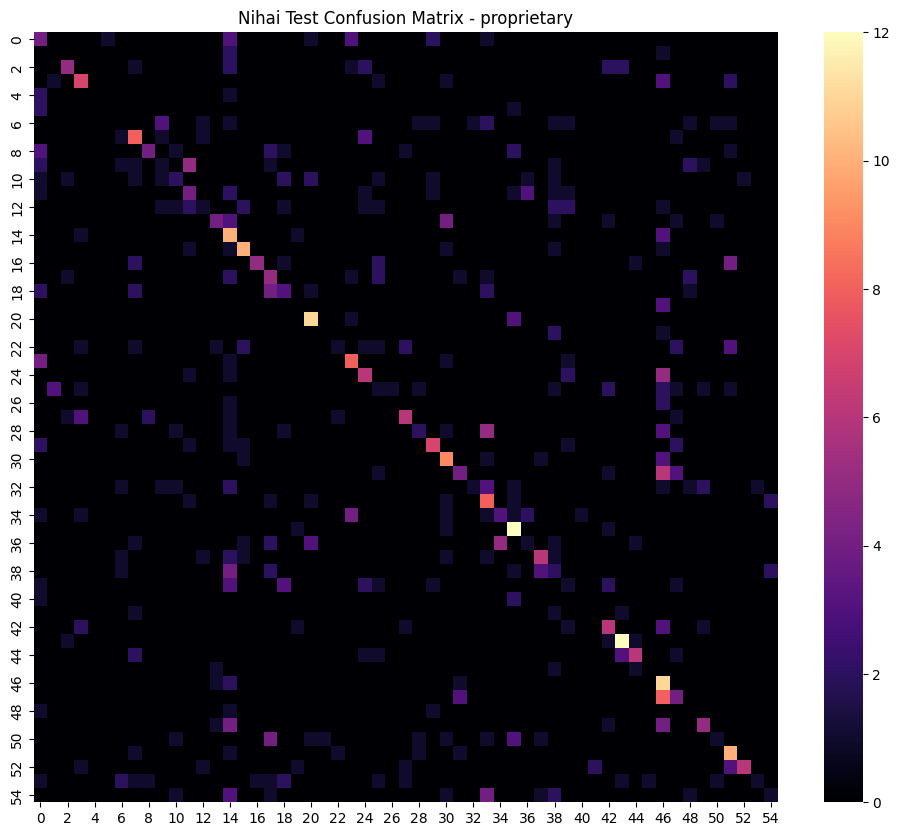

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm import tqdm
import numpy as np

# 1. Overflow Hatasını Önlemek İçin Dinamik Yama (Monkey Patch)
def safe_forward(self, feats: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    x = self.input_norm(feats)
    x = self.proj(x)
    x = self.pos_enc(x)
    x = self.transformer(x, src_key_padding_mask=~mask)
    w = self.attn_pool(x)
    # HATA ÇÖZÜMÜ: -1e4, FP16 (c10::Half) için güvenli bir sınırdır
    w = w.masked_fill(~mask.unsqueeze(-1), -1e4)
    w = torch.softmax(w.float(), dim=1).to(x.dtype)
    pooled = (x * w).sum(dim=1)
    return self.classifier(self.norm(pooled))

# Yama işlemini uygula
TemporalHead.forward = safe_forward

def compute_top_k_recall(logits, labels, k=5):
    _, topk_indices = torch.topk(logits, k, dim=1)
    correct = topk_indices.eq(labels.view(-1, 1).expand_as(topk_indices))
    return correct.any(dim=1).float().mean().item()

@torch.no_grad()
def run_final_test_end_to_end(cfg, checkpoint_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"--- FİNAL TEST BAŞLATILIYOR (Phase 2 Modu) ---")

    # 1. Hazırlıklar
    label_to_id = load_label_map(cfg.data_root, cfg.dataset_tag)

    test_dataset = VideoDataset(
        root=cfg.data_root,
        split="test",
        dataset_tag=cfg.dataset_tag,
        label_to_id=label_to_id,
        max_frames=cfg.max_frames,
        roi_size=cfg.roi_size
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=getattr(cfg, 'p2_batch_size', 1),
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=getattr(cfg, 'num_workers', 0),
        pin_memory=True
    )

    # 2. Model ve Ağırlık Yükleme
    model = FullModel(cfg).to(device)
    print(f"Ağırlıklar yükleniyor: {checkpoint_path}")

    ckpt = torch.load(checkpoint_path, map_location=device)
    state_dict = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt
    model.load_state_dict(state_dict)
    model.eval()

    all_logits, all_preds, all_labels = [], [], []

    # 3. Tahmin Döngüsü
    for seq, mask, labels in tqdm(test_loader, desc="Test Verisi İşleniyor"):
        seq, mask, labels = seq.to(device), mask.to(device), labels.to(device)

        with torch.amp.autocast("cuda"):
            logits = model(seq, mask)

        all_logits.append(logits.cpu())
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # 4. Sonuçları Hesapla
    all_logits_tensor = torch.cat(all_logits)
    all_labels_tensor = torch.tensor(all_labels)
    metrics = compute_metrics(all_labels, all_preds, cfg.num_classes)

    # Precision metriği eklendi
    precision_val = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall_val = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall_at_5 = compute_top_k_recall(all_logits_tensor, all_labels_tensor, k=5)

    # 5. Raporlama
    print(f"\n" + "="*40)
    print(f"Accuracy:      {metrics['accuracy']:.4f}")
    print(f"Precision:     {precision_val:.4f}") # Eklendi
    print(f"Recall@1:      {recall_val:.4f}")
    print(f"Recall@5:      {recall_at_5:.4f}")
    print(f"Weighted F1:   {metrics['f1_weighted']:.4f}")
    print(f"="*40)

    # Confusion Matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(metrics['confusion_matrix'], annot=False, cmap='magma')
    plt.title(f"Nihai Test Confusion Matrix - {cfg.dataset_tag}")
    plt.show()

# --- ÇALIŞTIRMA ---
run_final_test_end_to_end(cfg, "/content/checkpoints/dinov2_proprietary_phase2/best_model.pt")